# 4. Конфаундеры, специфичность, интерпретация

Можно ли результат объяснить чем-то, кроме физиологии покоя?

| Раздел | Вопрос |
| --- | --- |
| 4.2 | формат выгрузки и партия |
| 4.3 | качество записи |
| 4.4 | отведения T3/T4 |
| 4.5 | возраст |
| 4.6 | время решения таблиц |
| 4.7–4.8 | вклады признаков и ложноположительные |

Все вероятности — OOF протокола 8; диагностические модели используют те же фолды.

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "results" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score

from model.model import load
from src import confounders, config, dataset, evaluation, models, viz

warnings.filterwarnings("ignore", message="The least populated class")
warnings.filterwarnings("ignore", message="Mean of empty slice")
viz.apply_style()
pd.set_option("display.precision", 3)
VALIDATION = ROOT / "results" / "validation" / "protocol8"
P8 = models.PROTOCOL_8

data = models.load_training_data(protocol=P8)
keys = list(data.subject_keys)
oof = pd.read_csv(VALIDATION / "nested_oof.csv", index_col=0).loc[keys]
registry, _, subjects = dataset.scan_dataset(config.DATA_DIR)
final = load(ROOT / "model" / "weights")
stratum, groups = data.stratum, data.groups
ptsd = stratum == models.STRATUM_PTSD
YOUNG = ("control_A", "control_B", "control_C", "control_B_supplement")
SLICES = {
    "нормы < 65": YOUNG,
    "нормы A, B, доп.": ("control_A", "control_B", "control_B_supplement"),
    "все нормы формата B": ("control_B", "control_B_supplement", "control_ageing"),
    **{viz.STRATUM_LABELS[s]: (s,) for s in viz.STRATUM_ORDER[1:]},
}


def auc_slices(p: np.ndarray) -> pd.Series:
    """AUC of PTSD vs each negative slice for scores ``p`` (n_subjects,)."""
    out = {}
    for name, negatives in SLICES.items():
        mask = ptsd | np.isin(stratum, negatives)
        out[name] = roc_auc_score(ptsd[mask], p[mask])
    return pd.Series(out)


model_auc = auc_slices(oof["p_raw"].to_numpy())

## 4.2 Формат и партия

Модель только на метаданных экспорта показывает, сколько даёт одно знание формата. Внутри формата B (нормы B, доп. партия, 65+) формат одинаков у обоих классов.

In [2]:
meta_oof = pd.read_csv(VALIDATION / "metadata_oof.csv", index_col=0).loc[keys]
format_table = pd.DataFrame({"сдаваемая модель (OOF)": model_auc, "только метаданные экспорта": auc_slices(meta_oof["p"].to_numpy())})
format_table["испытуемых в срезе"] = [int(np.isin(stratum, s).sum()) for s in SLICES.values()]
format_table.rename_axis("AUC ПТСР против …")

,сдаваемая модель (OOF),только метаданные экспорта,испытуемых в срезе
AUC ПТСР против …,,,
нормы < 65,0.864,0.607,107
"нормы A, B, доп.",0.765,0.323,62
все нормы формата B,0.839,0.000,65
норма A,0.670,1.000,20
норма B,0.460,0.000,2
норма C,1.000,1.000,45
доп. нормы,0.828,0.000,40
нормы 65+,0.890,0.000,23
соматоформные,0.792,1.000,74


- Метаданные дают AUC 1.00 против нормы A, C и соматоформных и 0.00 против всех норм формата B.
- **Внутри формата B модель различает ПТСР и 65 норм с AUC 0.84** — это не формат.
- Против нормы C AUC 1.00 и у модели, и у метаданных: это не физиологический маркер.
- Различие партий регистрации внутри формата B этими данными не исключается.

## 4.3 Качество записи

Две диагностические модели: доли годных окон и флаги копий по каналам; то же плюс индикаторы пропусков признаков.

In [3]:
quality = confounders.quality_descriptors(keys)
x_quality = quality.to_numpy(dtype=float)
x_missing = np.isnan(data.tables[final.metadata["feature_set"]]).astype(float)
quality_table = pd.DataFrame({
    "сдаваемая модель (OOF)": model_auc,
    "качество записи": auc_slices(confounders.diagnostic_oof(data, x_quality)),
    "качество + пропуски признаков": auc_slices(confounders.diagnostic_oof(data, np.hstack([x_quality, x_missing]))),
})
quality_table.rename_axis("AUC ПТСР против …")

,сдаваемая модель (OOF),качество записи,качество + пропуски признаков
AUC ПТСР против …,,,
нормы < 65,0.864,0.497,0.691
"нормы A, B, доп.",0.765,0.596,0.583
все нормы формата B,0.839,0.578,0.665
норма A,0.670,0.542,0.546
норма B,0.460,0.460,0.440
норма C,1.000,0.360,0.840
доп. нормы,0.828,0.630,0.609
нормы 65+,0.890,0.499,0.781
соматоформные,0.792,0.498,0.534


- Качество само по себе ПТСР не различает (AUC 0.50 против норм моложе 65).
- С пропусками — 0.69, за счёт нормы C и пожилых без альфа-пика; в модели пропуск заменяется медианой, и этот путь вклада почти не даёт.

## 4.4 Отведения T3 и T4

T3 стоит рядом с референтом и сильнее всего зависит от условий регистрации. Две проверки: замена признаков T3 (T3/T4) медианой только на тесте и переобучение без T3/T4.

In [4]:
t3 = [n for n in data.feature_names["rest_O1FpT_exp"] if n.endswith("_T3")]
t34 = [n for n in data.feature_names["rest_O1FpT_exp"] if n.endswith(("_T3", "_T4"))]
runs = {
    "сдаваемая модель": oof,
    "T3 → медиана на тесте": evaluation.nested_oof(data, P8, mask_at_test=t3),
    "T3, T4 → медиана на тесте": evaluation.nested_oof(data, P8, mask_at_test=t34),
    "переобучение без T3/T4": evaluation.nested_oof(data, models.restricted_protocol(P8, ["rest_O1Fp", "rest_O1Fp_exp"], "protocol8_no_T")),
}
t_table = pd.DataFrame({name: auc_slices(r["p_raw"].to_numpy()) for name, r in runs.items()}).T
t_table["чувствительность при 0.5"] = [np.mean(r["p"].to_numpy()[ptsd] >= 0.5) for r in runs.values()]
t_table["специфичность 65+ и соматоформных"] = [
    np.mean(r["p"].to_numpy()[np.isin(stratum, ["control_ageing", "somatoform"])] < 0.5) for r in runs.values()]
t_table[["нормы < 65", "нормы A, B, доп.", "норма A", "доп. нормы", "нормы 65+", "соматоформные",
         "чувствительность при 0.5", "специфичность 65+ и соматоформных"]]

,нормы < 65,"нормы A, B, доп.",норма A,доп. нормы,нормы 65+,соматоформные,чувствительность при 0.5,специфичность 65+ и соматоформных
сдаваемая модель,0.864,0.765,0.670,0.828,0.890,0.792,0.84,0.670
T3 → медиана на тесте,0.721,0.681,0.644,0.708,0.828,0.668,0.32,0.897
"T3, T4 → медиана на тесте",0.693,0.615,0.612,0.623,0.837,0.638,0.16,0.938
переобучение без T3/T4,0.720,0.572,0.544,0.597,0.897,0.658,0.64,0.691


- Замена T3 медианой снижает AUC против норм моложе 65 с 0.86 до 0.72.
- **Без T3/T4 различение с молодыми нормами A/B почти исчезает (0.57)**, с пожилыми сохраняется (0.90).
- Различение ПТСР и молодых норм держится на височных отведениях; физиологию и различие партий здесь не разделить. Это главное ограничение модели.

## 4.5 Возраст

Можно ли предсказать возраст по тем же признакам внутри нормы? Гребневая регрессия, leave-one-group-out; R² ≤ 0 — признаки не знают о возрасте больше среднего.

In [5]:
x_model = data.tables[final.metadata["feature_set"]]
age = subjects.loc[keys, "age"].to_numpy(dtype=float)
age_sets = {
    "нормы < 65, все форматы": np.isin(stratum, YOUNG),
    "нормы < 65 без формата C": np.isin(stratum, ("control_A", "control_B", "control_B_supplement")),
    "только доп. партия (17–41 год)": stratum == "control_B_supplement",
    "все нормы, включая 65+": np.isin(stratum, (*YOUNG, "control_ageing")),
}
age_rows, age_pred = {}, {}
for name, m in age_sets.items():
    pred, ref = confounders.age_prediction_oof(x_model[m], age[m], groups[m])
    age_pred[name] = pred
    age_rows[name] = {
        "норм": int(m.sum()),
        "R² вне выборки": 1 - np.sum((pred - age[m]) ** 2) / np.sum((ref - age[m]) ** 2),
        "MAE модели, лет": np.mean(np.abs(pred - age[m])),
        "MAE по среднему, лет": np.mean(np.abs(ref - age[m])),
    }
pd.DataFrame(age_rows).T

,норм,R² вне выборки,"MAE модели, лет","MAE по среднему, лет"
"нормы < 65, все форматы",107.0,0.150,8.502,9.769
нормы < 65 без формата C,62.0,-0.029,6.615,6.640
только доп. партия (17–41 год),40.0,-0.383,5.650,5.053
"все нормы, включая 65+",130.0,0.287,12.552,15.553


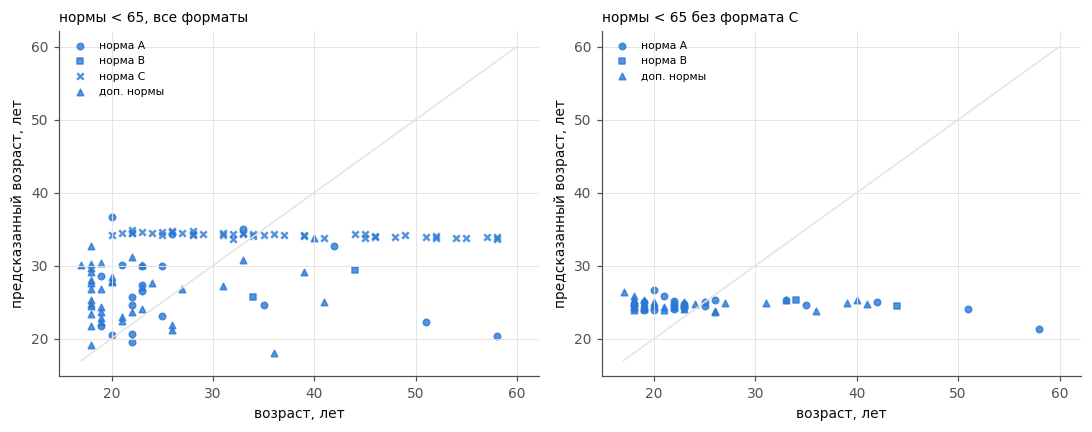

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.0))
for ax, name in zip(axes, ["нормы < 65, все форматы", "нормы < 65 без формата C"]):
    m = age_sets[name]
    for s, marker in [("control_A", "o"), ("control_B", "s"), ("control_C", "x"), ("control_B_supplement", "^")]:
        sel = stratum[m] == s
        if sel.any():
            ax.scatter(age[m][sel], age_pred[name][sel], marker=marker, s=18, color=viz.COHORT_COLORS[config.GROUP_CONTROL],
                       alpha=0.8, label=viz.STRATUM_LABELS[s])
    ax.plot([17, 60], [17, 60], color=viz.GRID, lw=1)
    ax.set_xlabel("возраст, лет")
    ax.set_ylabel("предсказанный возраст, лет")
    ax.set_title(name, loc="left", fontsize=9)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

**P против возраста внутри партий** (ранговая корреляция Спирмена):

In [7]:
corr_rows = {}
for name, negatives in {"нормы < 65, все форматы": YOUNG, **{viz.STRATUM_LABELS[s]: (s,) for s in ("control_A", "control_C", "control_B_supplement", "control_ageing")}}.items():
    m = np.isin(stratum, negatives)
    r = spearmanr(age[m], oof["p_raw"].to_numpy()[m])
    corr_rows[name] = {"норм": int(m.sum()), "возраст, лет": f"{age[m].min():.0f}–{age[m].max():.0f}",
                       "ρ Спирмена (P, возраст)": r.statistic, "p-значение": r.pvalue}
pd.DataFrame(corr_rows).T

,норм,"возраст, лет","ρ Спирмена (P, возраст)",p-значение
"нормы < 65, все форматы",107,17–58,-0.303,0.002
норма A,20,19–58,-0.087,0.715
норма C,45,20–58,-0.19,0.211
доп. нормы,40,17–41,-0.084,0.607
нормы 65+,23,65–70,-0.151,0.491


- Внутри партии признаки возраст не кодируют: R² 0.15 только за счёт формата C (для него предсказание почти постоянно), без формата C — −0.03.
- С нормами 65+ R² 0.29: у пожилых слабее и медленнее альфа. Это работает на специфичность (AUC 0.89 против 65+).
- P не зависит от возраста внутри партий (|ρ| ≤ 0.19); общая корреляция −0.30 возникает из состава партий.

Метрики по возрастным подгруппам — ноутбук 3, раздел 3.7.

## 4.6 Время решения таблиц

Не сводится ли P к медлительности? Корреляция P со временем первой таблицы и суммой пяти таблиц внутри каждой страты (формат C исключён).

In [8]:
times = confounders.schulte_times(registry).reindex(keys)
beh_rows = {}
for s in ("ptsd", "control_A", "control_ageing", "somatoform"):
    for col, label in [("trial1_s", "первая таблица"), ("total_s", "сумма пяти таблиц")]:
        m = (stratum == s) & times[col].notna().to_numpy()
        if m.sum() < 8:
            continue
        r = spearmanr(times[col].to_numpy()[m], oof["p_raw"].to_numpy()[m])
        beh_rows[(viz.STRATUM_LABELS[s], label)] = {"испытуемых": int(m.sum()), "ρ Спирмена (P, время)": r.statistic, "p-значение": r.pvalue}
pd.DataFrame(beh_rows).T

испытуемых  ρ Спирмена (P, время)  p-значение
ПТСР          первая таблица           25.0                 -0.048       0.821
              сумма пяти таблиц        25.0                 -0.125       0.553
норма A       первая таблица           20.0                  0.158       0.506
              сумма пяти таблиц        20.0                 -0.117       0.624
нормы 65+     первая таблица           23.0                  0.018       0.936
соматоформные первая таблица           72.0                 -0.195       0.101
              сумма пяти таблиц        68.0                 -0.342       0.004

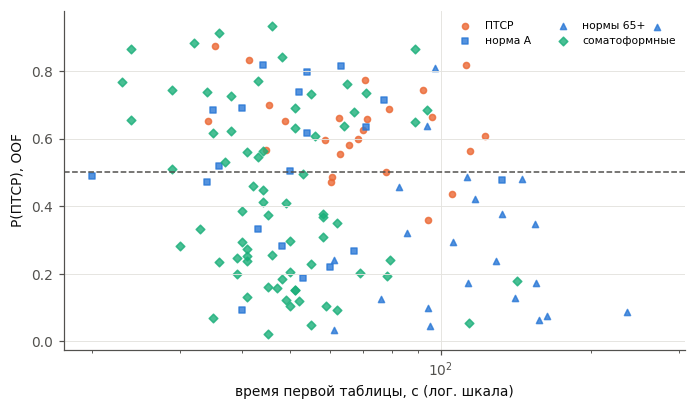

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
for s, marker in [("ptsd", "o"), ("control_A", "s"), ("control_ageing", "^"), ("somatoform", "D")]:
    m = (stratum == s) & times["trial1_s"].notna().to_numpy()
    ax.scatter(times["trial1_s"].to_numpy()[m], oof["p"].to_numpy()[m], s=16, marker=marker, color=viz.stratum_color(s),
               alpha=0.8, label=viz.STRATUM_LABELS[s])
ax.set_xscale("log")
ax.axhline(0.5, color=viz.TEXT_MUTED, ls="--", lw=1)
ax.set_xlabel("время первой таблицы, с (лог. шкала)")
ax.set_ylabel("P(ПТСР), OOF")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

- Внутри ПТСР, нормы A и 65+ P со временем решения не связана; у соматоформных связь отрицательная (ρ = −0.33).
- Пожилые решают медленнее всех, но получают низкую P: оценка не сводится к времени решения.

## 4.7 Вклады признаков

Логарифм шансов — сумма вкладов `w_j · z_j` (z — признак, стандартизованный по обучению). Ниже — средний вклад по стратам и медианы признаков.

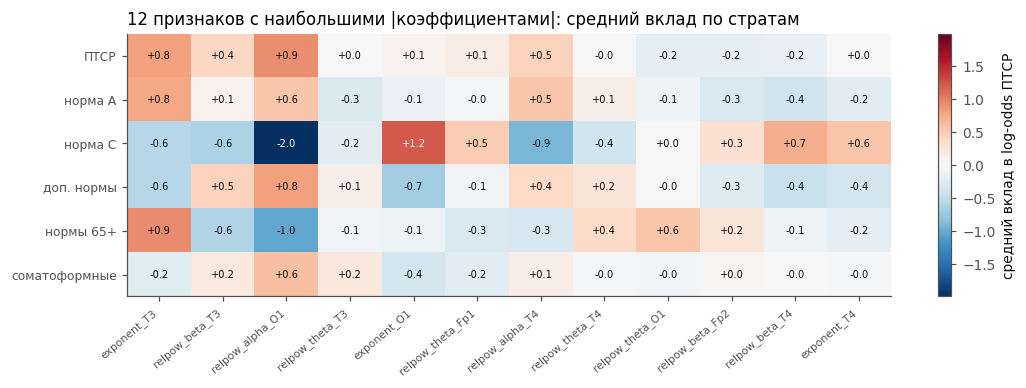

In [10]:
contrib = pd.DataFrame(confounders.feature_contributions(final, x_model), index=keys, columns=final.feature_names)
order = pd.Series(np.abs(final.coef), index=final.feature_names).sort_values(ascending=False).index[:12]
shown = [s for s in viz.STRATUM_ORDER if np.sum(stratum == s) >= 5]
mean_contrib = contrib[order].groupby(stratum).mean().reindex(shown).rename(index=viz.STRATUM_LABELS)
fig, ax = plt.subplots(figsize=(10, 3.6))
lim = float(np.nanmax(np.abs(mean_contrib.to_numpy())))
im = ax.imshow(mean_contrib.to_numpy(), cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(len(order)), [c.replace("rest_", "") for c in order], rotation=40, ha="right", fontsize=7)
ax.set_yticks(range(len(mean_contrib)), mean_contrib.index, fontsize=8)
ax.grid(False)
for (i, j), v in np.ndenumerate(mean_contrib.to_numpy()):
    ax.text(j, i, f"{v:+.1f}", ha="center", va="center", fontsize=6.5, color="white" if abs(v) > 0.6 * lim else "#0b0b0b")
fig.colorbar(im, ax=ax, label="средний вклад в log-odds ПТСР")
ax.set_title("12 признаков с наибольшими |коэффициентами|: средний вклад по стратам", loc="left")
plt.tight_layout()
plt.show()

In [11]:
raw = pd.DataFrame(x_model, index=keys, columns=final.feature_names)
medians = raw[order].groupby(stratum).median().reindex(list(viz.STRATUM_ORDER)).rename(index=viz.STRATUM_LABELS).T
medians.insert(0, "коэффициент", pd.Series(final.coef, index=final.feature_names)[order])
medians

,коэффициент,ПТСР,норма A,норма B,норма C,доп. нормы,нормы 65+,соматоформные
rest_exponent_T3,-2.546,0.904,0.958,0.340,1.042,1.029,0.786,0.911
rest_relpow_beta_T3,-1.779,-0.378,-0.413,-0.275,-0.340,-0.433,-0.294,-0.383
rest_relpow_alpha_O1,1.601,-0.394,-0.385,-0.371,-0.776,-0.370,-0.649,-0.430
rest_relpow_theta_T3,1.162,-0.536,-0.564,-0.717,-0.580,-0.490,-0.536,-0.499
rest_exponent_O1,-1.121,0.716,0.783,0.285,0.180,0.979,0.628,0.861
rest_relpow_theta_Fp1,0.886,-0.401,-0.465,-0.533,-0.357,-0.455,-0.473,-0.439
rest_relpow_alpha_T4,0.862,-0.500,-0.472,-0.559,-0.734,-0.535,-0.648,-0.575
rest_relpow_theta_T4,0.839,-0.572,-0.562,-0.581,-0.652,-0.512,-0.548,-0.579
rest_relpow_theta_O1,0.777,-0.715,-0.680,-0.936,-0.695,-0.650,-0.569,-0.663
rest_relpow_beta_Fp2,0.716,-0.522,-0.501,-0.508,-0.459,-0.584,-0.424,-0.526


ПТСР и норма A получают почти одинаковые вклады — модель их плохо различает. Норма C получает низкую P через отсутствие альфы, 65+ — через слабую альфу, доп. партия — через более крутой спектр T3 и O1.

| Признак | Отведение, диапазон | При ПТСР | Трактовка |
| --- | --- | --- | --- |
| наклон спектра | T3, 3–30 Гц | ↓ (площе): 0.90 против 0.96 у нормы A | согласуется с Kovacevic et al. (2025), но на T3 сильно зависит от партии — главный кандидат на конфаундинг |
| доля беты | T3, 13–30 Гц | ≈ | условный эффект при том же наклоне |
| доля альфы | O1, 8–13 Гц | ≈ (как у молодых норм) | отделяет пожилых со слабой альфой; маркером ПТСР не является |
| доля теты | Fp1, T3, T4, O1; 4–8 Гц | ↑ слегка | сниженное бодрствование, нарушения сна; эффект слабый |
| наклон спектра | O1, 3–30 Гц | ↓ (площе): 0.72 против 0.78 | согласуется с литературой; неспецифичен — так же при старении |
| лобная асимметрия | Fp2 − Fp1, 8–13 Гц | ≈ | прироста не дала |

Подробнее — `docs/CLINICAL_INTERPRETATION.md`.

## 4.8 Ложноположительные у 65+ и соматоформных

Разность средних вкладов признаков: ложноположительные минус верно отнесённые.

In [12]:
p = oof["p"].to_numpy()
fp_rows = {}
for s in ("control_ageing", "somatoform"):
    m = stratum == s
    fp, tn = m & (p >= 0.5), m & (p < 0.5)
    fp_rows[f"{viz.STRATUM_LABELS[s]}: ложноположительные ({fp.sum()}) − верные ({tn.sum()})"] = (
        contrib[fp].mean() - contrib[tn].mean())
fp_table = pd.DataFrame(fp_rows)
fp_table.loc[fp_table.abs().max(axis=1).sort_values(ascending=False).index[:8]]

,нормы 65+: ложноположительные (3) − верные (20),соматоформные: ложноположительные (29) − верные (45)
rest_relpow_alpha_O1,0.428,1.359
rest_relpow_alpha_T4,1.028,0.690
rest_exponent_O1,0.983,0.057
rest_exponent_T3,0.732,0.548
rest_relpow_beta_Fp2,-0.688,-0.152
rest_relpow_beta_T3,0.531,0.637
rest_relpow_theta_O1,-0.316,-0.462
rest_relpow_theta_Fp1,0.381,0.293


- **Соматоформные** (29 из 74): у ложноположительных сохранная затылочная альфа — модель не отличает ПТСР от соматоформных с похожим спектром покоя.
- **65+** (3 из 23): пожилые с сохранной альфой и более плоским спектром O1 — «молодая» ЭЭГ.

## 4.9 Выводы

**Не объясняет результат:** формат (внутри формата B AUC 0.84), качество записи (AUC 0.50), возраст внутри партии (R² ≈ 0), время решения таблиц.

**Ограничения:**
1. Различение с молодыми нормами опирается на T3/T4 (без них 0.57 против норм A/B).
2. Против нормы A различение слабое (0.67), высокий AUC против норм моложе 65 во многом за счёт формата C.
3. Специфичность на соматоформных 0.61.

**Итог:** модель уверенно отделяет ПТСР от нормального старения, и это не объясняется конфаундерами; различение с молодыми нормами слабее и держится на височных отведениях.

## 4.10 Общий профиль или признак ПТСР

ТЗ требует, чтобы модель реагировала на признак травмы, а не на любое отклонение от нормы. У ПТСР часто есть тревога и депрессия, поэтому для каждого признака сравниваются три пары: ПТСР против молодых норм A/B, соматоформные против нормы A (тот же формат выгрузки — чистое клиническое сравнение) и ПТСР против соматоформных. «Общий» — признак сдвинут у обеих клинических групп в одну сторону; «отличает ПТСР» — сдвинут только у ПТСР или отличает ПТСР от соматоформных. ДИ — бутстрэп, 1000 повторов.

In [13]:
x_df = pd.DataFrame(x_model, index=keys, columns=final.feature_names)
spec_table = confounders.disorder_specificity(x_df, stratum, ("control_A", "control_B", "control_B_supplement"))
spec_table.sort_values("вывод")

,ПТСР / нормы,соматоформные / норма A,ПТСР / соматоформные,"ПТСР / соматоформные, 95% ДИ",вывод
rest_relpow_theta_O1,0.428,0.522,0.435,[0.32; 0.56],нет различий
rest_exponent_T3,0.398,0.550,0.425,[0.29; 0.57],нет различий
rest_exponent_Fp2,0.456,0.451,0.498,[0.36; 0.63],нет различий
rest_exponent_Fp1,0.505,0.454,0.538,[0.41; 0.67],нет различий
rest_exponent_O1,0.377,0.554,0.399,[0.26; 0.54],нет различий
rest_alpha_peak_O1,0.530,0.470,0.588,[0.46; 0.70],нет различий
rest_iaf_O1,0.388,0.686,0.366,[0.22; 0.51],нет различий
rest_relpow_beta_T3,0.518,0.494,0.486,[0.35; 0.63],нет различий
rest_relpow_beta_Fp2,0.530,0.567,0.439,[0.31; 0.58],нет различий
rest_relpow_beta_O1,0.501,0.470,0.476,[0.35; 0.61],нет различий


- **Надёжно сдвинуты у ПТСР только два признака, и оба общие с соматоформными:** более плоский спектр на T4 (0.32 у ПТСР, 0.39 у соматоформных) и больше беты на T4 (0.62 и 0.65). Это профиль гипервозбуждения, характерный для клинических групп вообще.
- **Ни один признак не отличает именно ПТСР при 95% ДИ.** Слабые кандидаты: более плоский спектр на O1 (ПТСР против соматоформных 0.40 [0.26; 0.54]), чуть больше лобной теты (0.60 [0.48; 0.73]) и более медленная альфа (0.37 [0.22; 0.51]).
- ПТСР (формат B) и соматоформные (формат A) выгружены по-разному, поэтому и эти кандидаты могут отражать формат.

**Вывод:** у ПТСР и соматоформных общий сдвиг признаков, но итоговая P у соматоформных ниже, чем у нормы A того же формата (медиана 0.37 против 0.51, AUC 0.38). Значит, соматоформных (AUC 0.79) отделяют не клинические признаки; возможный конфаундер — пол (ПТСР — только мужчины, у соматоформных оба пола). Общий профиль (бета и плоский спектр) совпадает и с фармако-ЭЭГ бензодиазепинов. Признака, специфичного именно для травмы, эти данные не показывают: нет группы с травмой без ПТСР, нет групп с депрессией и тревогой, нет стимулов, связанных с травмой.

## 4.11 Клиническая интерпретация

- ПТСР и контроль различаются не только диагнозом: боевая травма, ЧМТ, лекарства, сон (ТЗ §3.4). P — сходство с ЭЭГ клинической когорты, а не вероятность травмы у человека.
- Затылочная альфа при ПТСР не ослаблена (высота пика 0.89, как у молодых норм); ожидаемого по литературе эффекта в этих данных нет.
- Спектр O1 у ПТСР немного площе, лобная тета чуть выше — согласуется с гипервозбуждением и нарушениями сна, но эффекты малы и неспецифичны.
- Мышечное напряжение на височных отведениях не подтверждается: доля 30–40 Гц на T3/T4 у ПТСР как у нормы A и соматоформных; отличается только доп. партия.
- Соматоформные — клинически самая близкая группа (тревога, соматическое возбуждение, травматический опыт, похожая терапия); большинство отличий ПТСР от нормы есть и у них (раздел 4.10).
- Специфичность на сопоставимых молодых нормах (A, B, доп. партия) — 0.52; LR+ ≈ 1.7, LR− ≈ 0.31. При распространённости 10% положительный результат верен лишь в ~16% случаев, отрицательный — в ~97%. Модель не диагностический инструмент.
- Поведение: темп у ПТСР равномерно снижен в 1.23–1.34 раза, врабатываемость как у нормы A (1.13), истощаемости нет (устойчивость 0.95) — не астенический профиль.

Подробно — `docs/CLINICAL_INTERPRETATION.md`.